In [1]:
import requests
import pandas as pd
import numpy as np
import re
import json
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from collections import Counter
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings

warnings.filterwarnings('ignore')

# === КОНСТАНТЫ ПУТЕЙ И API ===
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7"
}
MAX_WORKERS = 4
SAMPLE_SIZE = 10000
OUTPUT_FILE = "new_steam_games.csv"
CLEANED_FILE = "cleaned_steam_games.csv"
SOURCE_JSON = "paid_steam_games_full.json"
ALLAPP_JSON = "games.json"
OUTPUT_DIR = "output"
DPI = 150
ENCODING = "utf-8-sig"

SPY_DETAIL_URL = "https://steamspy.com/api.php?request=appdetails&appid={}"
API_DETAIL_URL = "https://store.steampowered.com/api/appdetails?appids={}&l=russian"
REVIEWS_URL = "https://store.steampowered.com/appreviews/{}?json=1&filter=all&language=all&{}&num_per_page=1"
NEWS_URL = "https://api.steampowered.com/ISteamNews/GetNewsForApp/v2/?appid={}&count=1&maxlength=50&format=json"

# === КОНСТАНТЫ СТОЛБЦОВ ===
COL_APPID = "AppID"
COL_GAME = "Игра"
COL_DEVELOPER = "Разработчик"
COL_PUBLISHER = "Издатель"
COL_OWNERS = "Примерное кол-во владельцев (среднее)"
COL_TAGS = "Популярные теги (20)"
COL_GENRES = "Жанры"
COL_LANGUAGES = "Количество языков"
COL_CCU = "Пиковый онлайн вчера (CCU)"
COL_RELEASE_DATE = "Дата выхода"
COL_EARLY_ACCESS = "Ранний доступ"
COL_PRICE = "Цена"
COL_WINDOWS = "Windows"
COL_MACOS = "MacOS"
COL_LINUX = "Linux"
COL_SINGLEPLAYER = "Одиночная игра"
COL_MULTIPLAYER = "Мультиплеерная игра"
COL_CLOUD = "Облако"
COL_ACHIEVEMENTS = "Достижения"
COL_FAMILY_SHARE = "Family Share"
COL_VR = "VR"
COL_STEAMDECK = "SteamDeck"
COL_METACRITIC = "Рейтинг Metacritic"
COL_RECENT_REVIEWS = "Недавние отзывы"
COL_ALL_REVIEWS = "Все отзывы"
COL_REVIEWS_COUNT = "Количество отзывов"
COL_LAST_UPDATE = "Дата последнего обновления"
COL_REVENUE = "Доход (оценка)"
COL_YEAR = "Год выпуска"

BOOL_COLS = [
    COL_EARLY_ACCESS, COL_WINDOWS, COL_MACOS, COL_LINUX,
    COL_SINGLEPLAYER, COL_MULTIPLAYER, COL_CLOUD, COL_ACHIEVEMENTS,
    COL_FAMILY_SHARE, COL_VR, COL_STEAMDECK
]
NUM_COLS_WITH_SPACES = [COL_OWNERS, COL_CCU, COL_REVIEWS_COUNT, COL_LANGUAGES]
LIST_COLS = [COL_TAGS, COL_GENRES]

os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# === ФУНКЦИИ ПАРСИНГА STEAM ===

def parse_release_date(date_str):
    if not date_str or date_str in ["N/A", "Скоро", "Coming Soon", "TBA"]:
        return pd.NaT
    clean_str = date_str.replace(" г.", "").strip()
    month_map = {
        "янв.": "Jan", "фев.": "Feb", "мар.": "Mar", "апр.": "Apr",
        "мая": "May", "май": "May", "июн.": "Jun", "июл.": "Jul",
        "авг.": "Aug", "сен.": "Sep", "окт.": "Oct", "ноя.": "Nov", "дек.": "Dec"
    }
    for ru, en in month_map.items():
        if ru in clean_str:
            clean_str = clean_str.replace(ru, en)
            break
    try:
        return datetime.strptime(clean_str, "%d %b %Y")
    except ValueError:
        return pd.NaT

def get_steamspy_data(appid):
    try:
        r = requests.get(SPY_DETAIL_URL.format(appid), headers=HEADERS, timeout=10)
        if "application/json" not in r.headers.get("Content-Type", ""): return None
        data = r.json()
        if data.get("appid") == 999999: return None

        owners_avg = "N/A"
        m = re.search(r"([\d,]+)\s*\.\.\s*([\d,]+)", data.get("owners", "0 .. 0"))
        if m:
            avg = (int(m.group(1).replace(",","")) + int(m.group(2).replace(",",""))) // 2
            owners_avg = f"{avg:,}".replace(",", " ")

        tags_list = []
        tags_raw = data.get("tags", {})
        if isinstance(tags_raw, dict):
            tags_list = [tag[0] for tag in sorted(tags_raw.items(), key=lambda x: x[1], reverse=True)[:20]]

        genre_raw = data.get("genre", "")
        genres_list = [g.strip() for g in genre_raw.split(",") if g.strip()] if isinstance(genre_raw, str) and genre_raw else []

        languages_raw = data.get("languages")
        lang_count = len(languages_raw) if isinstance(languages_raw, list) else len([x.strip() for x in languages_raw.split(",")]) if isinstance(languages_raw, str) and languages_raw.strip() else 0

        return {
            "Игра": data.get("name", "N/A"), "Разработчик": data.get("developer", "N/A"),
            "Издатель": data.get("publisher", "N/A"), "Примерное кол-во владельцев (среднее)": owners_avg,
            "Популярные теги (20)": ", ".join(tags_list) if tags_list else "N/A",
            "Жанры": ", ".join(genres_list) if genres_list else "N/A",
            "Количество языков": lang_count, "Пиковый онлайн вчера (CCU)": f"{data.get('ccu', 0):,}".replace(",", " ")
        }
    except Exception: return None

def get_steam_api_data(appid):
    try:
        r = requests.get(API_DETAIL_URL.format(appid), headers=HEADERS, timeout=10)
        data = r.json().get(str(appid), {})
        if not data.get("success"): return {}
        app = data["data"]
        categories = [cat["description"].lower() for cat in app.get("categories", [])]
        check = lambda kws: any(k in " ".join(categories) for k in kws)

        if app.get("is_free"): price = "Бесплатно"
        elif "price_overview" in app: price = app["price_overview"].get("final_formatted", "N/A")
        else: price = "N/A"

        return {
            "Дата выхода": parse_release_date(app.get("release_date", {}).get("date", "N/A")),
            "Ранний доступ": "Ранний доступ" in app.get("name", "") or app.get("release_date", {}).get("coming_soon", False),
            "Цена": price, "Windows": app.get("platforms", {}).get("windows", False),
            "MacOS": app.get("platforms", {}).get("mac", False), "Linux": app.get("platforms", {}).get("linux", False),
            "Одиночная игра": check(["для одного игрока", "single-player"]),
            "Мультиплеерная игра": check(["многопользовательская", "multi-player", "coop"]),
            "Облако": check(["облачные сохранения", "cloud"]), "Достижения": check(["достижения", "achievements"]),
            "Family Share": check(["семейный доступ", "family sharing"]), "VR": check(["vr"]),
            "SteamDeck": check(["steam deck", "deck verified"]),
            "Рейтинг Metacritic": f"{app.get('metacritic', {}).get('score', 'N/A')}/100" if "metacritic" in app else "N/A"
        }
    except Exception: return {}

def get_reviews(appid):
    res = {"Недавние отзывы": 0.0, "Все отзывы": 0.0, "Количество отзывов": "0"}
    try:
        for url_suffix, key in [("day_range=30", "Недавние отзывы"), ("day_range=all", "Все отзывы")]:
            r = requests.get(REVIEWS_URL.format(appid, url_suffix), headers=HEADERS, timeout=10).json()
            if r.get("success") == 1 and "query_summary" in r:
                q = r["query_summary"]
                total, pos = q.get("total_reviews", 0), q.get("total_positive", 0)
                res[key] = round(pos / total, 4) if total > 0 else 0.0
                if key == "Недавние отзывы": res["Количество отзывов"] = f"{total:,}".replace(",", " ")
    except Exception: pass
    return res

def get_last_update(appid):
    try:
        r = requests.get(NEWS_URL.format(appid), headers=HEADERS, timeout=10).json()
        if "appnews" in r and "newsitems" in r["appnews"] and r["appnews"]["newsitems"]:
            return datetime.fromtimestamp(r["appnews"]["newsitems"][0]["date"])
    except Exception: pass
    return pd.NaT

def parse_game(appid):
    print(f"📥 AppID {appid}...", end=" ")
    spy_data, api_data = get_steamspy_data(appid), get_steam_api_data(appid)
    if not spy_data and not api_data:
        print("❌ Недоступна")
        return None

    game_name = spy_data.get("Игра", "N/A") if spy_data else api_data.get("Игра", "N/A")
    developer = spy_data.get("Разработчик", "N/A") if spy_data else api_data.get("Разработчик", "N/A")
    publisher = spy_data.get("Издатель", "N/A") if spy_data else api_data.get("Издатель", "N/A")

    final_data = {
        "AppID": appid, "Игра": game_name, "Разработчик": developer, "Издатель": publisher,
        "Примерное кол-во владельцев (среднее)": spy_data.get("Примерное кол-во владельцев (среднее)", "N/A") if spy_data else "N/A (Блок)",
        "Популярные теги (20)": spy_data.get("Популярные теги (20)", "N/A") if spy_data else "N/A",
        "Жанры": spy_data.get("Жанры", "N/A") if spy_data else "N/A (Блок)",
        "Количество языков": spy_data.get("Количество языков", 0) if spy_data else 0,
        "Пиковый онлайн вчера (CCU)": spy_data.get("Пиковый онлайн вчера (CCU)", "N/A") if spy_data else "N/A (Блок)",
        "Дата выхода": api_data.get("Дата выхода", pd.NaT), "Ранний доступ": api_data.get("Ранний доступ", False),
        "Цена": api_data.get("Цена", "N/A"), "Windows": api_data.get("Windows", False),
        "MacOS": api_data.get("MacOS", False), "Linux": api_data.get("Linux", False),
        "Одиночная игра": api_data.get("Одиночная игра", False), "Мультиплеерная игра": api_data.get("Мультиплеерная игра", False),
        "Облако": api_data.get("Облако", False), "Достижения": api_data.get("Достижения", False),
        "Family Share": api_data.get("Family Share", False), "VR": api_data.get("VR", False),
        "SteamDeck": api_data.get("Steam Deck", False), "Рейтинг Metacritic": api_data.get("Рейтинг Metacritic", "N/A"),
        "Недавние отзывы": 0.0, "Все отзывы": 0.0, "Количество отзывов": "0", "Дата последнего обновления": pd.NaT
    }

    final_data.update(get_reviews(appid))
    final_data["Дата последнего обновления"] = get_last_update(appid)
    print("✅" if spy_data else "⚠️ (Spy блок)")
    return final_data

def extract_appids_from_json_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f: data = json.load(f)
    if isinstance(data, list): return [item['appid'] for item in data if isinstance(item, dict) and 'appid' in item]
    elif isinstance(data, dict) and 'appid' in data: return [data['appid']]
    return []

def load_appids_from_steam_apps_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as f: data = json.load(f)
    if isinstance(data, dict): return [int(k) for k in data.keys() if k.isdigit()]
    return []

def load_existing_dataset(file_path):
    if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
        try:
            df = pd.read_csv(file_path, encoding='utf-8-sig')
            return df, set(df['AppID'].astype(str).values) if 'AppID' in df.columns else set()
        except Exception: return pd.DataFrame(), set()
    return pd.DataFrame(), set()

def run_parser():
    appids_from_json = extract_appids_from_json_file(SOURCE_JSON)
    appids_from_steam_apps = load_appids_from_steam_apps_json(ALLAPP_JSON)

    app_ids = list(appids_from_json)
    if len(appids_from_steam_apps) > 0:
        app_ids.extend(random.sample(appids_from_steam_apps, min(SAMPLE_SIZE, len(appids_from_steam_apps))))

    existing_df, processed_ids = load_existing_dataset(OUTPUT_FILE)
    remaining = [a for a in app_ids if str(a) not in processed_ids]

    if not remaining: return

    total = len(remaining)
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_to_appid = {executor.submit(parse_game, int(appid)): appid for appid in remaining}
        for i, future in enumerate(as_completed(future_to_appid), 1):
            result = future.result(timeout=60)
            if result and str(result["AppID"]) not in processed_ids:
                header_needed = not os.path.exists(OUTPUT_FILE) or os.path.getsize(OUTPUT_FILE) == 0
                pd.DataFrame([result]).to_csv(OUTPUT_FILE, mode='a', header=header_needed, index=False, encoding='utf-8-sig')
                processed_ids.add(str(result["AppID"]))

In [28]:
# === ФУНКЦИИ ОЧИСТКИ ДАННЫХ ===

def find_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    mask1 = ((q1 - 1.5 * iqr) > data)
    mask2 = data > q3 + 1.5 * iqr
    return (mask1 | mask2)

def load_and_clean_raw_data(file_path):
    df = pd.read_csv(file_path, quotechar='"', encoding='utf-8', on_bad_lines='skip')
    df.dropna(axis=1, how='all', inplace=True)
    return df

def standardize_missing_values(df):
    df.replace(['N/A', 'n/a', 'NULL', 'null', 'None', '', ' '], np.nan, inplace=True)
    return df

def clean_price_column(df, column_name):
    if column_name not in df.columns: return df
    def parse_price(val):
        if pd.isna(val): return np.nan
        val_str = str(val).lower().strip()
        if 'бесплатно' in val_str or 'free' in val_str or val_str == '0': return 0.0
        val_str = val_str.replace(',', '.')
        try: return float(re.sub(r'[^\d.]', '', val_str))
        except ValueError: return np.nan
    df[column_name] = df[column_name].apply(parse_price)
    return df

def clean_numeric_with_spaces(df, column_name):
    if column_name not in df.columns: return df
    def parse_number(val):
        if pd.isna(val): return 0
        try: return int(str(val).replace(' ', '').replace(',', ''))
        except ValueError: return 0
    df[column_name] = df[column_name].apply(parse_number)
    return df

def clean_boolean_columns(df, columns_list):
    for col in columns_list:
        if col in df.columns:
            s = df[col].astype(str).str.strip().str.lower().map({
                'true': True, 'false': False, '1': True, '0': False,
                'yes': True, 'no': False, 'nan': np.nan, '': np.nan
            })
            df[col] = s.fillna(False).astype(int)
    return df

def clean_list_columns(df, column_name):
    if column_name not in df.columns:
        return df

    def parse_list(val):
        if pd.isna(val):
            return ''  # пустая строка вместо NaN

        # Если уже список, преобразуем его
        if isinstance(val, list):
            items = [str(item).strip() for item in val if str(item).strip()]
        else:
            # Если строка, разбиваем по запятой, убираем пробелы
            items = [item.strip() for item in str(val).split(',') if item.strip()]

        return ', '.join(items)  # объединяем через запятую и пробел

    df[column_name] = df[column_name].apply(parse_list)
    return df
def parse_metacritic(val):
    if pd.isna(val): return np.nan
    val_str = str(val).strip()
    try: return float(val_str.split('/')[0]) if '/' in val_str else float(val_str)
    except: return np.nan

def remove_demo_and_placeholder_rows(df):
    df_clean = df.copy()
    demo_keywords = ['demo', 'playtest', 'soundtrack', ' ost ', 'dlc', 'expansion']
    keyword_mask = df_clean[COL_GAME].astype(str).str.lower().str.contains('|'.join(demo_keywords), na=False)

    p = pd.to_numeric(df_clean[COL_PRICE], errors='coerce').fillna(0)
    r = pd.to_numeric(df_clean[COL_REVIEWS_COUNT], errors='coerce').fillna(0)
    empty_metrics_mask = (p == 0) & (r == 0)

    author_mask = df_clean[COL_DEVELOPER].isna() | (df_clean[COL_DEVELOPER].astype(str).str.strip() == "")
    publisher_mask = df_clean[COL_PUBLISHER].isna() | (df_clean[COL_PUBLISHER].astype(str).str.strip() == "")
    empty_game_name_mask = df_clean[COL_GAME].isna() | (df_clean[COL_GAME].astype(str).str.strip() == "")

    drop_mask = keyword_mask | (empty_metrics_mask & author_mask & publisher_mask) | empty_game_name_mask
    return df_clean[~drop_mask].copy()

def process_steam_dataset(file_path):
    df = load_and_clean_raw_data(file_path)
    df = standardize_missing_values(df)
    df = clean_price_column(df, COL_PRICE)
    for col in NUM_COLS_WITH_SPACES: df = clean_numeric_with_spaces(df, col)
    df = clean_boolean_columns(df, BOOL_COLS)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

    for col in LIST_COLS: df = clean_list_columns(df, col)

    df[COL_METACRITIC] = df[COL_METACRITIC].apply(parse_metacritic)

    num_cols = [COL_PRICE, COL_RECENT_REVIEWS, COL_ALL_REVIEWS]
    for col in num_cols:
        if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    valid_mask = pd.Series(True, index=df.index)

    for col in num_cols:
        if col in df.columns:
            valid_mask &= ~find_outliers(df[col])
    df = df[valid_mask].reset_index(drop=True)

    return remove_demo_and_placeholder_rows(df)

In [32]:
# === ФУНКЦИИ АНАЛИЗА И ВИЗУАЛИЗАЦИИ ===

def format_large_numbers(x, pos=None):
    if x >= 1e9: return f'{x/1e9:.1f}B'
    elif x >= 1e6: return f'{x/1e6:.1f}M'
    elif x >= 1e3: return f'{x/1e3:.1f}K'
    return f'{x:.0f}'

def format_with_commas(x, pos=None):
    return f'{int(x):,}'

def correlation_heatmap(df, numeric_cols):
    corr_matrix = df[numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Матрица корреляций")
    plt.tight_layout()
    plt.xticks(rotation=45, ha="right")
    plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap.png"), dpi=DPI)
    plt.show()


def safe_extract_tags(series):
    all_tags = []
    for val in series.dropna():
        if isinstance(val, str): all_tags.extend([t.strip() for t in val.split(',') if t.strip()])
        elif isinstance(val, list): all_tags.extend([t.strip() for t in val if t.strip()])
    return all_tags

def get_top_n(series, n=3):
    return dict(Counter(safe_extract_tags(series)).most_common(n))

def plot_publisher_stats(df):
    df_pub = df.dropna(subset=[COL_PUBLISHER]).copy()
    publisher_group = df_pub.groupby(COL_PUBLISHER)

    publisher_stats = pd.DataFrame({
        'Количество игр': publisher_group.size(),
        'Суммарный доход': publisher_group[COL_REVENUE].sum()
    })

    top_tags = publisher_group[COL_TAGS].apply(get_top_n, n=3)
    top_genres = publisher_group[COL_GENRES].apply(get_top_n, n=3)

    publisher_stats['Топ-3 тега'] = top_tags.apply(lambda d: ', '.join(d.keys()) if isinstance(d, dict) else '')
    publisher_stats['Топ-3 жанра'] = top_genres.apply(lambda d: ', '.join(d.keys()) if isinstance(d, dict) else '')

    publisher_stats.index.name = 'Издатель'
    publisher_stats = publisher_stats.sort_values('Суммарный доход', ascending=False).reset_index()

    top10_by_revenue = publisher_stats.head(10)
    plt.figure()
    sns.barplot(data=top10_by_revenue, x='Суммарный доход', y='Издатель', hue='Издатель', palette='viridis', legend=False)
    plt.title('Топ-10 издателей по оценке дохода')
    plt.xlabel('Суммарный доход (оценка)')
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'top_publishers_by_revenue.png'), dpi=DPI, bbox_inches='tight')
    plt.show()

    top10_by_count = publisher_stats.sort_values('Количество игр', ascending=False).head(10)
    plt.figure()
    sns.barplot(data=top10_by_count, x='Количество игр', y='Издатель', hue='Издатель', palette='magma', legend=False)
    plt.title('Топ-10 издателей по количеству игр')
    plt.xlabel('Количество игр')
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'top_publishers_by_count.png'), dpi=DPI, bbox_inches='tight')
    plt.show()

    plt.figure()
    sns.scatterplot(data=publisher_stats, x='Количество игр', y='Суммарный доход',
                    size='Количество игр', sizes=(20, 500), alpha=0.6, legend=False)
    for _, row in publisher_stats.head(5).iterrows():
        plt.text(row['Количество игр'], row['Суммарный доход'], row['Издатель'], fontsize=9, ha='right', va='bottom')
    plt.xlabel('Количество игр')
    plt.ylabel('Суммарный доход (оценка)')
    plt.title('Зависимость дохода от количества игр у издателей')
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))
    plt.tight_layout()
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'revenue_vs_count.png'), dpi=DPI, bbox_inches='tight')
    plt.show()

    return publisher_stats

def plot_yearly_dynamics(df):
    df_years = df.dropna(subset=[COL_RELEASE_DATE]).copy()
    df_years['Год'] = df_years[COL_RELEASE_DATE].dt.year
    df_years = df_years[(df_years['Год'] >= 1970) & (df_years['Год'] <= pd.Timestamp.now().year)]

    games_per_year = df_years.groupby('Год').size().reset_index(name='Количество игр').sort_values('Год')

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=games_per_year, x='Год', y='Количество игр', marker='o', color='steelblue', linewidth=2)
    plt.title('Количество выпущенных игр по годам')
    plt.xlabel('Год')
    plt.ylabel('Количество игр')
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'games_per_year.png'), dpi=DPI, bbox_inches='tight')
    plt.show()

def tag_correlation(df, numeric_cols):
    all_user_tags = set()
    for tags_str in df[COL_TAGS].dropna():
        for tag in str(tags_str).split(','):
            tag = tag.strip()
            if tag:
                all_user_tags.add(tag)

    user_tag_dummies = df[COL_TAGS].str.get_dummies(sep=', ').add_prefix('UserTag_')
    developer_tag_cols = numeric_cols
    dev_tags_present = [c for c in developer_tag_cols if c in df.columns]
    df_dev_tags = df[dev_tags_present].copy()

    combined = pd.concat([user_tag_dummies, df_dev_tags], axis=1)

    min_freq = 500
    user_freq = user_tag_dummies.sum()
    user_tags_keep = user_freq[user_freq >= min_freq].index.tolist()
    user_tag_dummies_filtered = user_tag_dummies[user_tags_keep]

    dev_freq = df_dev_tags.sum()
    dev_tags_keep = dev_freq[dev_freq >= min_freq].index.tolist()
    df_dev_tags_filtered = df_dev_tags[dev_tags_keep]

    combined_filtered = pd.concat([user_tag_dummies_filtered, df_dev_tags_filtered], axis=1)
    corr_full = combined_filtered.corr()

    user_cols = user_tag_dummies_filtered.columns
    dev_cols = df_dev_tags_filtered.columns
    cross_corr = corr_full.loc[user_cols, dev_cols]

    plt.figure(figsize=(16, 12))
    sns.heatmap(cross_corr, annot=False, cmap='coolwarm', center=0,
                linewidths=0.5, cbar_kws={'label': 'Корреляция Пирсона'})
    plt.title('Корреляция между пользовательскими тегами и метриками')
    plt.xlabel('Метрики / Теги разработчиков')
    plt.ylabel('Пользовательские теги')
    plt.tight_layout()
    plt.xticks(rotation=45, ha="right")
    plt.savefig(os.path.join(OUTPUT_DIR, 'user_dev_tag_correlation.png'), dpi=DPI, bbox_inches='tight')
    plt.show()

    pairs = cross_corr.unstack().reset_index()
    pairs.columns = ['user_tag', 'dev_tag', 'correlation']
    pairs = pairs.dropna()

    print("\n=== Топ-5 положительных корреляций ===")
    print(pairs.sort_values('correlation', ascending=False).head(5))

    print("\n=== Топ-5 отрицательных корреляций ===")
    print(pairs.sort_values('correlation', ascending=True).head(5))

Пайплайн

In [ ]:
# === ЗАПУСК ПАРСЕРА ===
run_parser()

In [33]:
# === ЗАПУСК ОЧИСТКИ ДАННЫХ ===
df = process_steam_dataset(OUTPUT_FILE)

df[COL_RELEASE_DATE] = pd.to_datetime(df[COL_RELEASE_DATE], errors='coerce')
df[COL_YEAR] = df[COL_RELEASE_DATE].dt.year

df[COL_REVENUE] = df[COL_PRICE] * df[COL_OWNERS]

df.drop(columns=[COL_STEAMDECK, COL_MULTIPLAYER], inplace=True, errors='ignore')
df.to_csv(CLEANED_FILE, index=False, encoding=ENCODING, float_format='%.2f')

numeric_cols_base = [
    COL_PRICE, COL_OWNERS, COL_CCU, COL_RECENT_REVIEWS, COL_ALL_REVIEWS,
    COL_REVIEWS_COUNT, COL_METACRITIC, COL_REVENUE, COL_LANGUAGES
]
numeric_cols = [c for c in numeric_cols_base + BOOL_COLS if c in df.columns]

print(f"✅ Очищенные данные сохранены в {CLEANED_FILE}")
print(f"📊 Итоговый размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

✅ Очищенные данные сохранены в cleaned_steam_games.csv
📊 Итоговый размер датасета: 5432 строк, 27 столбцов


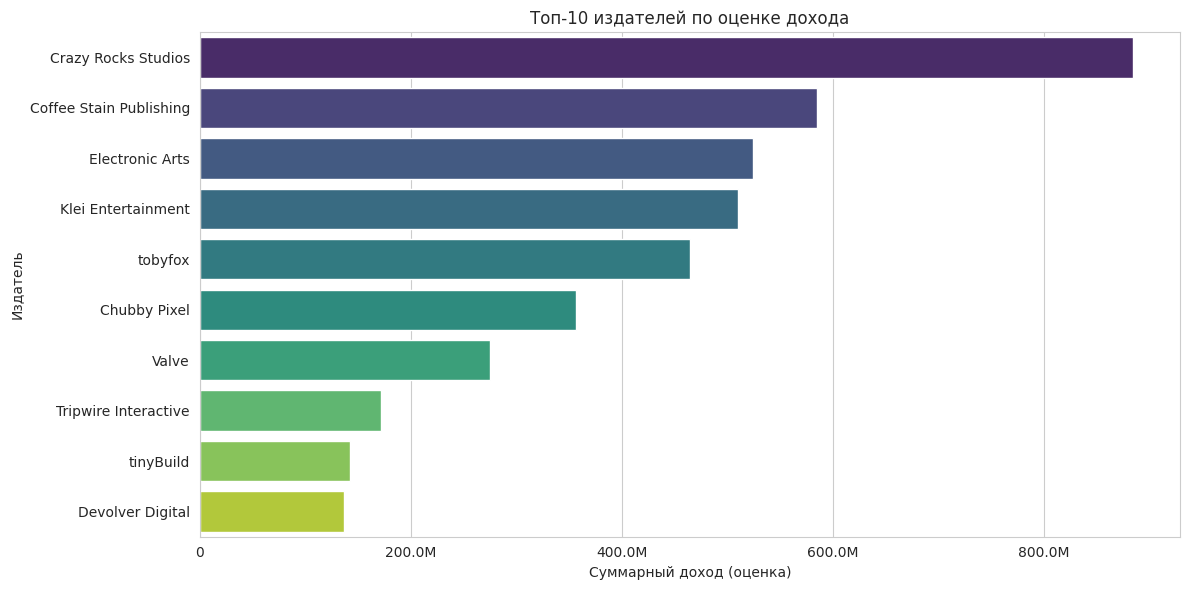

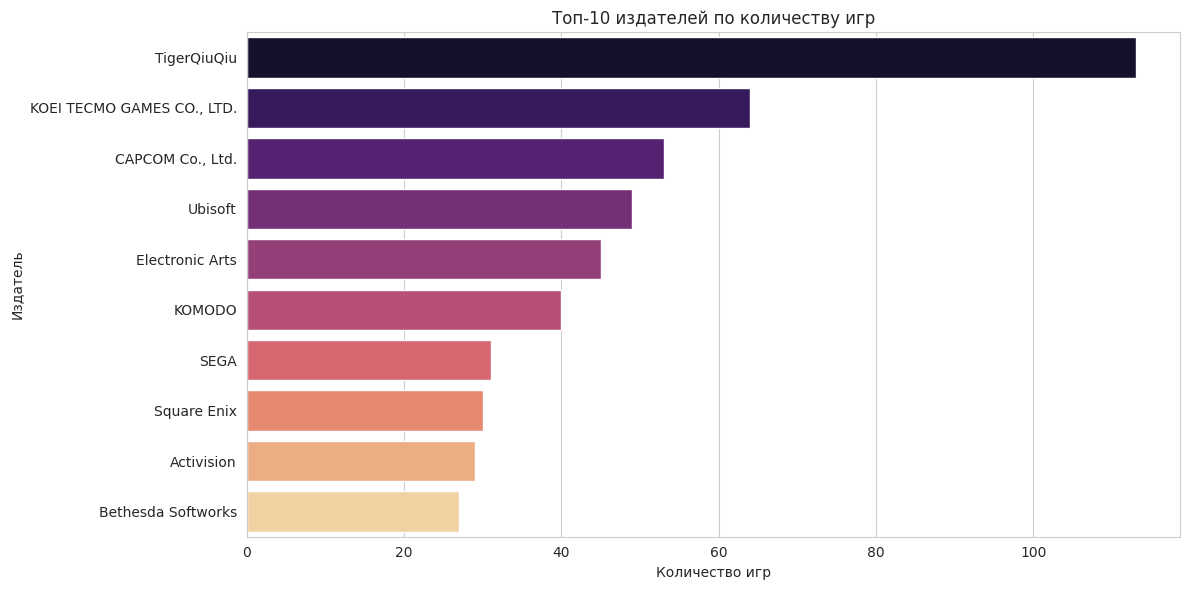

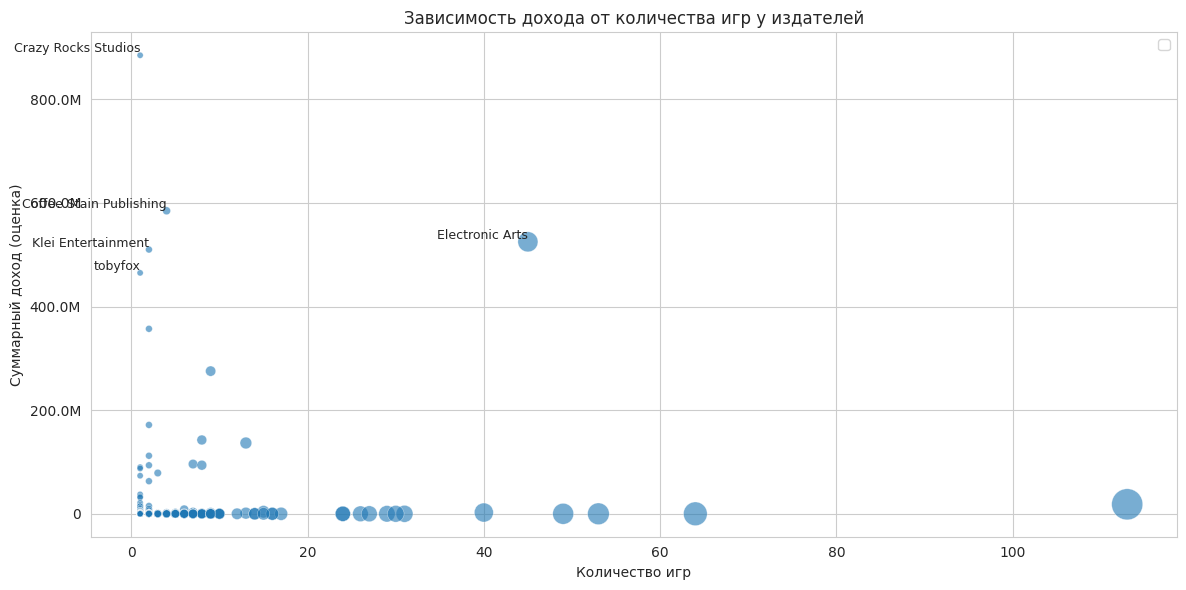

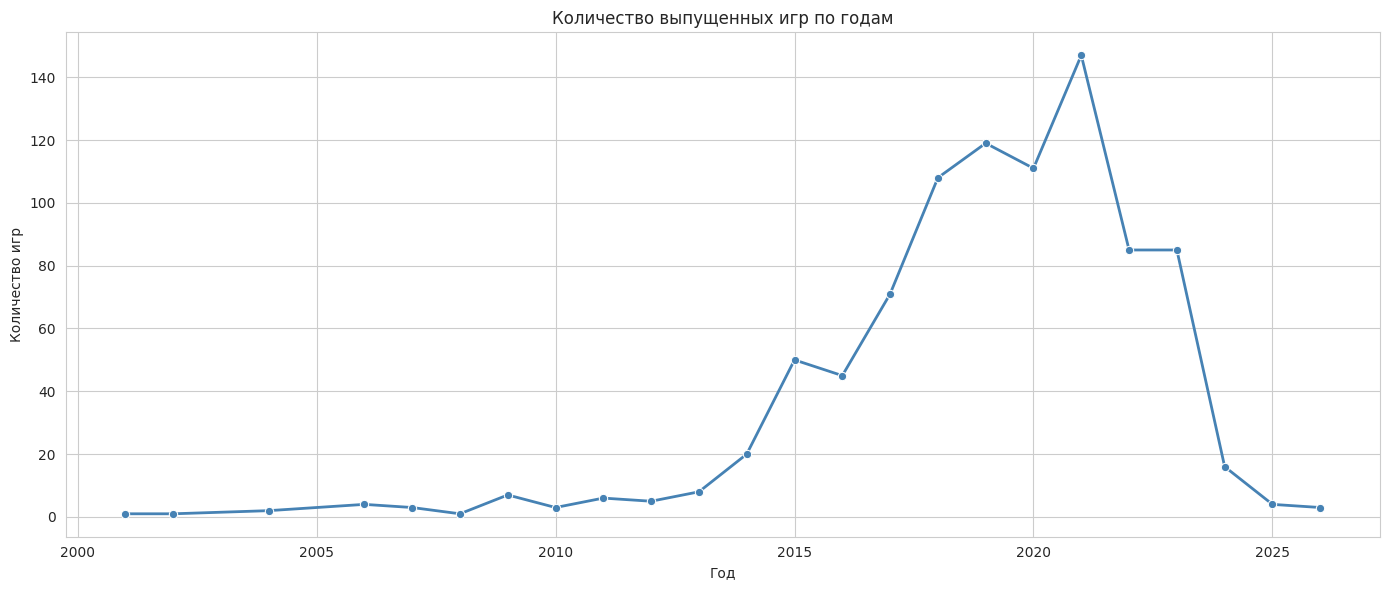

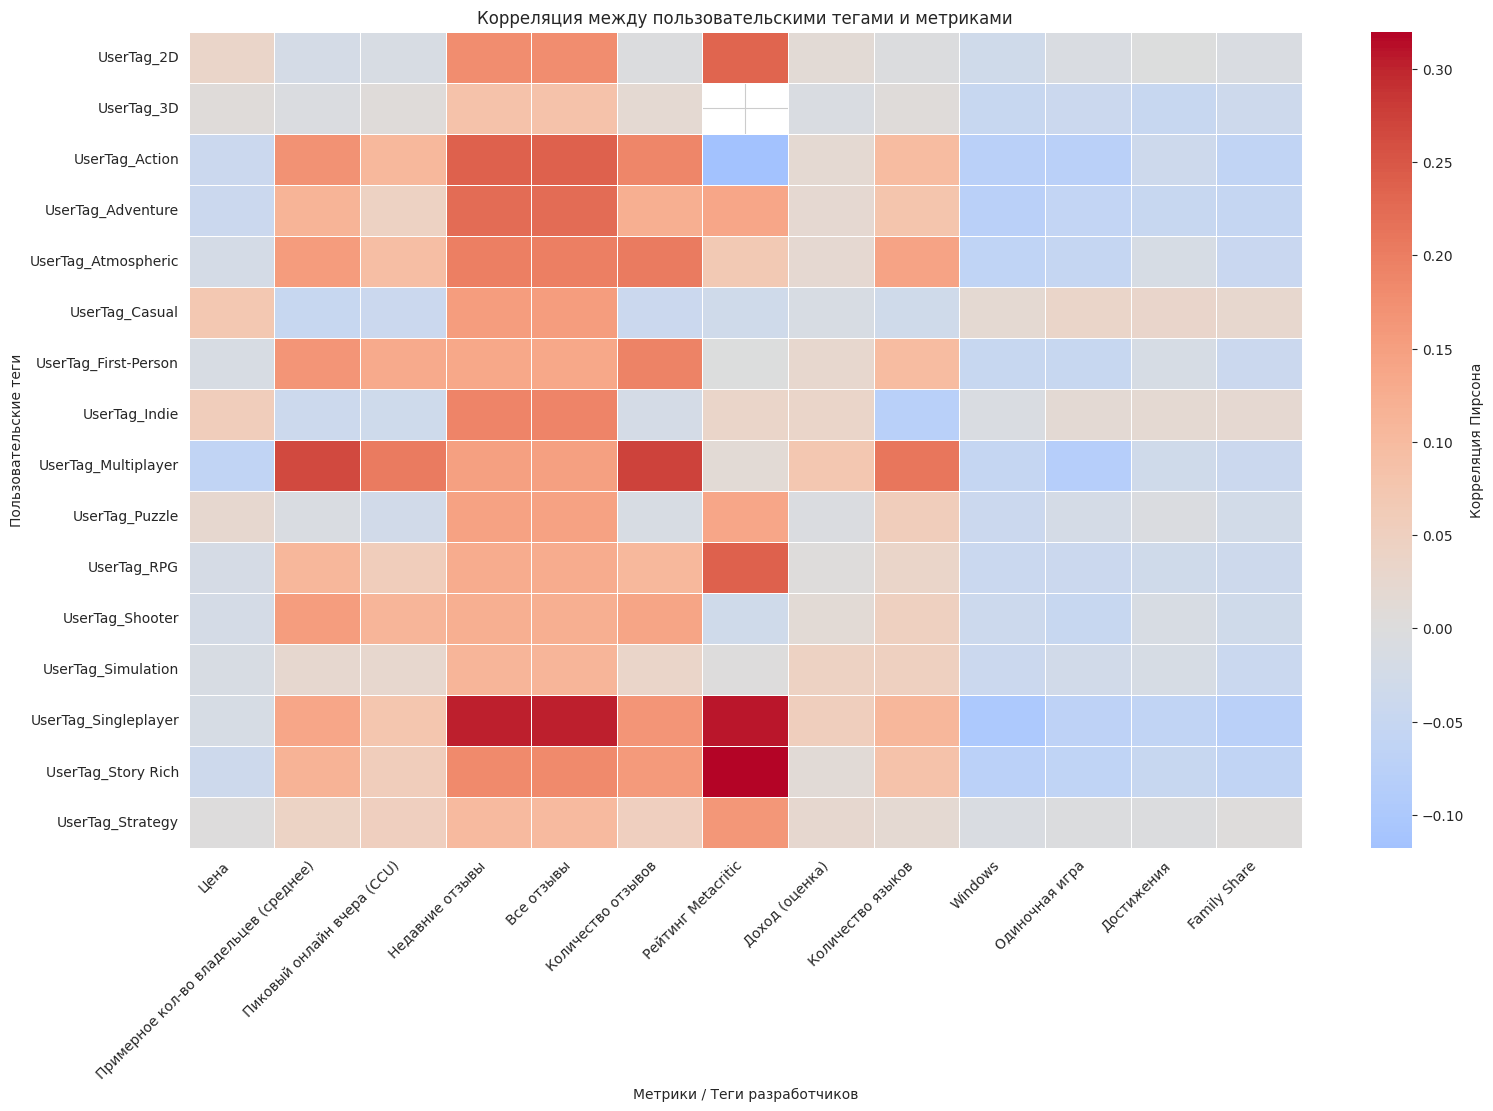


=== Топ-5 положительных корреляций ===
               user_tag               dev_tag  correlation
110  Рейтинг Metacritic    UserTag_Story Rich     0.319816
109  Рейтинг Metacritic  UserTag_Singleplayer     0.308781
77           Все отзывы  UserTag_Singleplayer     0.302949
61      Недавние отзывы  UserTag_Singleplayer     0.302949
88   Количество отзывов   UserTag_Multiplayer     0.273206

=== Топ-5 отрицательных корреляций ===
               user_tag               dev_tag  correlation
98   Рейтинг Metacritic        UserTag_Action    -0.117929
157             Windows  UserTag_Singleplayer    -0.100582
168      Одиночная игра   UserTag_Multiplayer    -0.083111
135   Количество языков         UserTag_Indie    -0.078128
162      Одиночная игра        UserTag_Action    -0.076124


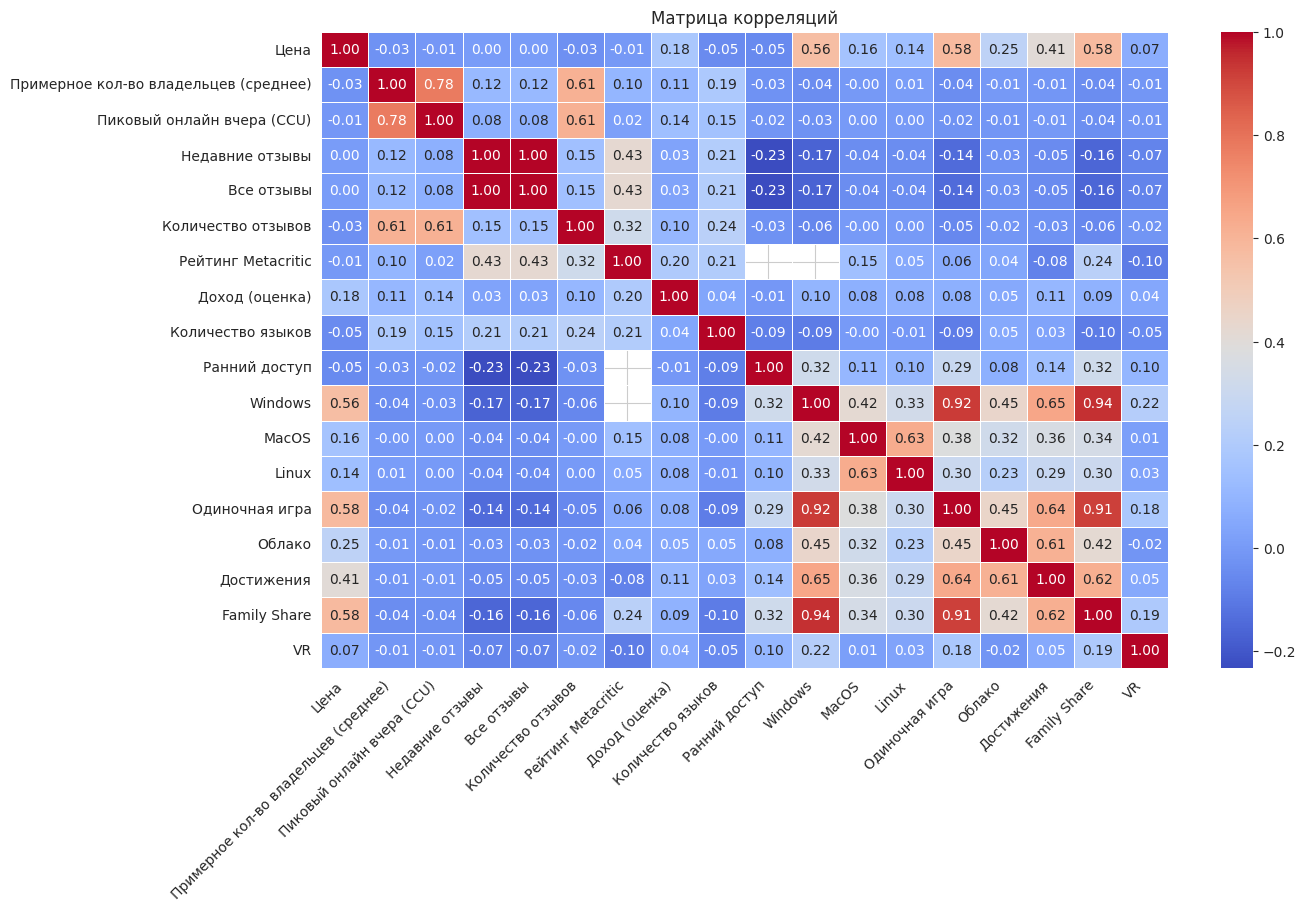


=== Топ-5 издателей по доходу ===
               Издатель  Суммарный доход  Количество игр Топ-3 жанра
    Crazy Rocks Studios      885000000.0               1         NaN
Coffee Stain Publishing      584850000.0               4         NaN
        Electronic Arts      524925000.0              45         NaN
     Klei Entertainment      510000000.0               2         NaN
                tobyfox      465000000.0               1         NaN


In [34]:
# === ЗАПУСК АНАЛИЗА И ГРАФИКОВ ===
publisher_stats = plot_publisher_stats(df)
plot_yearly_dynamics(df)
tag_correlation(df,numeric_cols=numeric_cols)
correlation_heatmap(df,numeric_cols=numeric_cols)
print("\n=== Топ-5 издателей по доходу ===")
print(publisher_stats.head(5)[['Издатель', 'Суммарный доход', 'Количество игр', 'Топ-3 жанра']].to_string(index=False))